In [13]:
# ===========================================================
# Cell 1: Imports and reproducibility
# ===========================================================
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng()


In [14]:
# ===========================================================
# Cell 2: Normal population
# ===========================================================
N = 300

mu = 50      # mean (e.g., Ω/sq or mS/cm)
sigma = 8    # standard deviation

population = rng.normal(mu, sigma, size=N)
population.sort()  # ordered population

population_mean = population.mean()
population_mean


np.float64(50.474978445566606)

In [15]:
# ===========================================================
# Cell 3: Simple random sampling (SRS)
# ===========================================================
n = 30

random_sample = rng.choice(population, size=n, replace=False)
random_sample.mean()


np.float64(51.58917622366629)

In [16]:
# ===========================================================
# Cell 4: Systematic sampling
# ===========================================================
k = int(np.ceil(N / n))       # sampling interval
start = rng.integers(0, k)   # random start

systematic_sample = population[start::k][:n]
systematic_sample.mean()


np.float64(50.582954314079096)

In [17]:
# ===========================================================
# Cell 5: Stratified sampling
# ===========================================================
n_strata = 5
samples_per_stratum = n // n_strata

strata = np.array_split(population, n_strata)

stratified_sample = np.concatenate([
    rng.choice(stratum, size=samples_per_stratum, replace=False)
    for stratum in strata
])

stratified_sample.mean()


np.float64(50.40437026465312)

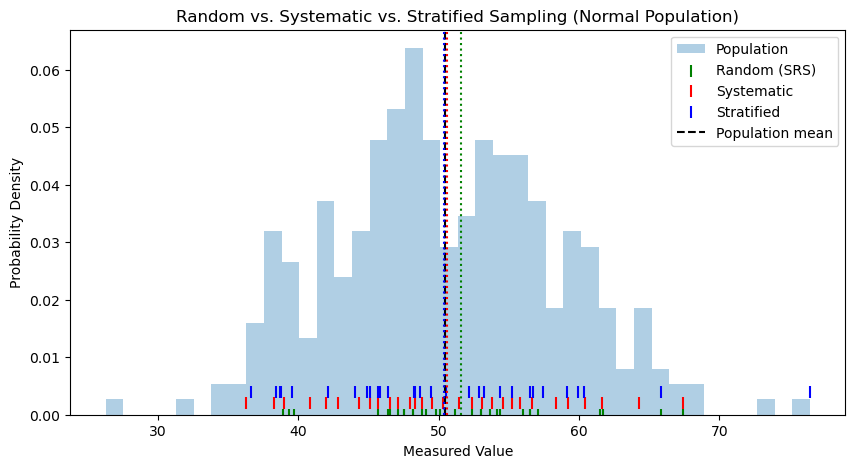

In [18]:
# ===========================================================
# Cell 6: Combined visualization
# ===========================================================
plt.figure(figsize=(10,5))

# Population
plt.hist(population, bins=40, density=True, alpha=0.35, label="Population")

# Samples plotted as tick marks
plt.scatter(random_sample, np.zeros_like(random_sample),
            color="green", marker="|", s=70, label="Random (SRS)")

plt.scatter(systematic_sample, np.zeros_like(systematic_sample) + 0.002,
            color="red", marker="|", s=70, label="Systematic")

plt.scatter(stratified_sample, np.zeros_like(stratified_sample) + 0.004,
            color="blue", marker="|", s=70, label="Stratified")

# Mean lines
plt.axvline(population_mean, color="k", linestyle="--", label="Population mean")
plt.axvline(random_sample.mean(), color="green", linestyle=":")
plt.axvline(systematic_sample.mean(), color="red", linestyle=":")
plt.axvline(stratified_sample.mean(), color="blue", linestyle=":")

plt.xlabel("Measured Value")
plt.ylabel("Probability Density")
plt.title("Random vs. Systematic vs. Stratified Sampling (Normal Population)")
plt.legend()
plt.show()
